In [1]:
pip install ultralytics opendatasets


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

# Base directory containing train/val/test folders
base_dir = r"C:\Users\akra0003\Desktop\JuypterInterior"
splits = ["train", "valid", "test"]

# Mapping: old class ID (your custom) → new class ID (COCO + custom)
id_mapping = {i: i + 80 for i in range(10)}  # 0→80, 1→81, ..., 9→89

def update_label_file(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if not parts or len(parts) < 5:
            continue
        old_id = int(parts[0])
        if old_id in id_mapping:
            parts[0] = str(id_mapping[old_id])
        new_lines.append(' '.join(parts))

    with open(file_path, 'w') as f:
        f.write('\n'.join(new_lines) + '\n')

# Loop through each split
for split in splits:
    label_dir = os.path.join(base_dir, split, 'labels')
    for file in os.listdir(label_dir):
        if file.endswith('.txt'):
            file_path = os.path.join(label_dir, file)
            update_label_file(file_path)

print("✅ Labels updated to match COCO+custom index range (80–89)")


✅ Labels updated to match COCO+custom index range (80–89)


In [3]:
import pandas as pd
import os

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from pathlib import Path
import shutil

In [5]:
from ultralytics import YOLO

# Load pre-trained YOLOv8 model (choose v8n, v8s, v8m, v8l)
model = YOLO('yolov8n.pt')  # or 'yolov8s.pt'

# Train the model
model.train(
    data=r"C:\Users\akra0003\Desktop\JuypterInterior\data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)


New https://pypi.org/project/ultralytics/8.3.173 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.172  Python-3.13.5 torch-2.7.1+cpu CPU (AMD EPYC 7V12 64-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\akra0003\Desktop\JuypterInterior\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train8, nbs=64, nms=Fals

train: Scanning C:\Users\akra0003\Desktop\JuypterInterior\train\labels.cache... 1008 images, 120 backgrounds, 81 corrup

train: C:\Users\akra0003\Desktop\JuypterInterior\train\images\000bf0ddff4c7310.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
train: C:\Users\akra0003\Desktop\JuypterInterior\train\images\000c052bb4b882c4.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
train: C:\Users\akra0003\Desktop\JuypterInterior\train\images\007427672a3d5264.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
train: C:\Users\akra0003\Desktop\JuypterInterior\train\images\007bae2adf43dd31.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
train: C:\Users\akra0003\Desktop\JuypterInterior\train\images\009ae3d6fd97c1fc.jpg: ignoring corrupt image/label: Label class 89 exceeds dataset class count 88. Possible class labels are 0-87
train: C:\Users\akra0003\Desktop\Juypter


C:\Users\akra0003\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning C:\Users\akra0003\Desktop\JuypterInterior\valid\labels.cache... 230 images, 31 backgrounds, 16 corrupt: 1

val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\000d61ba9ffa87db.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\00bb967bc89e040f.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\0118064eedc2b2c1.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\0bf8a1dc0827950f.jpg: ignoring corrupt image/label: Label class 89 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\0c0a7b8b641aa601.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\val

...

                   all        214       1181      0.639      0.534      0.585      0.394



50 epochs completed in 3.290 hours.
Optimizer stripped from runs\detect\train8\weights\last.pt, 6.7MB
Optimizer stripped from runs\detect\train8\weights\best.pt, 6.7MB

Validating runs\detect\train8\weights\best.pt...
Ultralytics 8.3.172  Python-3.13.5 torch-2.7.1+cpu CPU (AMD EPYC 7V12 64-Core Processor)
Model summary (fused): 72 layers, 3,224,552 parameters, 0 gradients, 9.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:13<0


                   all        214       1181      0.654      0.527      0.585      0.395
                  door         52         80       0.64      0.537      0.606      0.381
           cabinetDoor         93        731      0.825      0.683      0.785      0.443
      refrigeratorDoor         79        180      0.804      0.694      0.739      0.504
                window         33         81      0.448      0.259       0.26      0.131
                 table         20         38      0.806      0.553        0.7      0.422
               cabinet         28         38      0.335      0.184      0.232      0.123
            openedDoor         28         32      0.468      0.303      0.362       0.26
                  pole          1          1      0.906          1      0.995      0.895
Speed: 0.8ms preprocess, 44.7ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs\detect\train8


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([80, 81, 82, 83, 84, 85, 86, 87])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001ACC2A227B0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046, 

In [6]:
results = model.val()
print(results)

Ultralytics 8.3.172  Python-3.13.5 torch-2.7.1+cpu CPU (AMD EPYC 7V12 64-Core Processor)
Model summary (fused): 72 layers, 3,224,552 parameters, 0 gradients, 9.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 886.8659.9 MB/s, size: 215.5 KB)


val: Scanning C:\Users\akra0003\Desktop\JuypterInterior\valid\labels.cache... 230 images, 31 backgrounds, 16 corrupt: 1

val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\000d61ba9ffa87db.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\00bb967bc89e040f.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\0118064eedc2b2c1.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\0bf8a1dc0827950f.jpg: ignoring corrupt image/label: Label class 89 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\0c0a7b8b641aa601.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\val


C:\Users\akra0003\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:11


                   all        214       1181      0.651      0.518      0.582      0.394
                  door         52         80      0.632      0.525      0.589      0.366
           cabinetDoor         93        731      0.828      0.684       0.79      0.446
      refrigeratorDoor         79        180      0.784      0.689      0.741      0.508
                window         33         81       0.48      0.284      0.278      0.149
                 table         20         38      0.784      0.526      0.699      0.429
               cabinet         28         38      0.341      0.158       0.21      0.108
            openedDoor         28         32      0.459      0.281      0.351       0.25
                  pole          1          1      0.899          1      0.995      0.895
Speed: 0.5ms preprocess, 39.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs\detect\train82
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: a


image 1/1 C:\Users\akra0003\Downloads\livinig.jpg: 416x640 5 cabinetDoors, 2 windows, 1 cabinet, 1 openedDoor, 1 pole, 77.8ms
Speed: 2.4ms preprocess, 77.8ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 640)


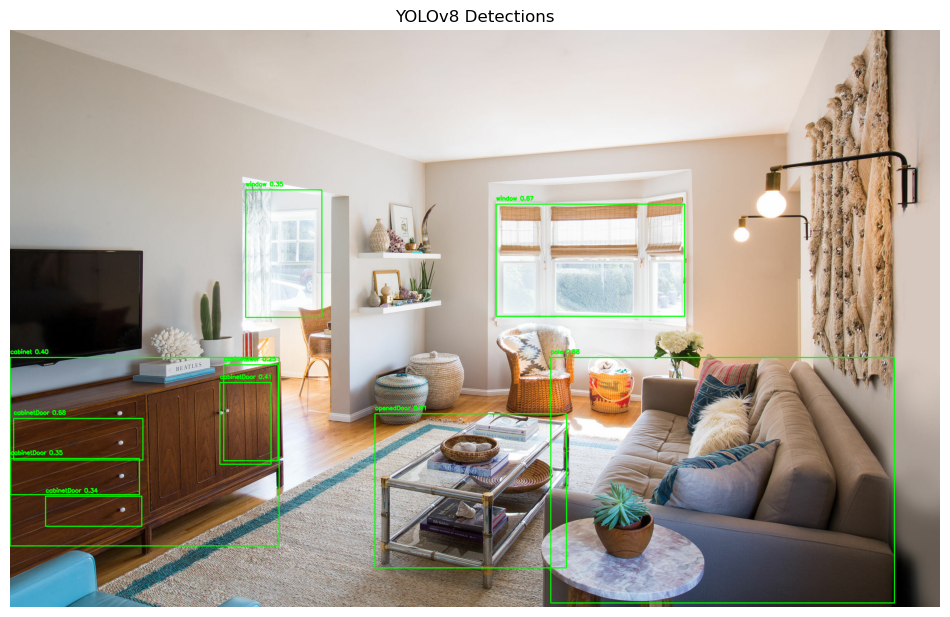

In [7]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt

# Image path
image_path = r"C:\Users\akra0003\Downloads\livinig.jpg"

# Run prediction
results = model.predict(source=image_path, save=False)

# Read image using OpenCV
image = cv2.imread(image_path)

# Check if image loaded successfully
if image is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

# Process detection results
for result in results:
    boxes = result.boxes
    for box in boxes:
        # Get coordinates and convert to int
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cls = int(box.cls[0])
        label = model.names.get(cls, f'class {cls}')

        # Draw rectangle
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Draw label
        text = f"{label} {conf:.2f}"
        cv2.putText(
            image, text, (x1, max(y1 - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2
        )

# Convert BGR to RGB (OpenCV uses BGR, matplotlib uses RGB)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display using matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.axis('off')
plt.title('YOLOv8 Detections')
plt.show()

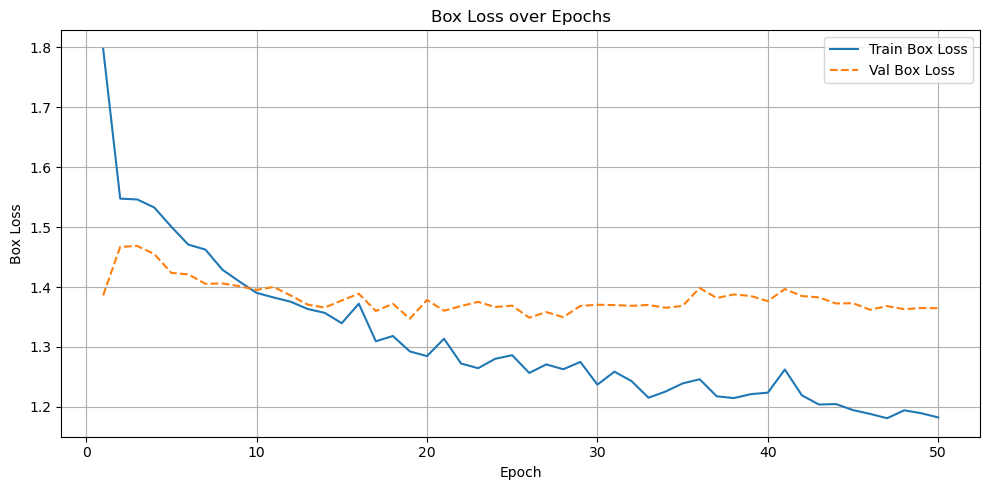

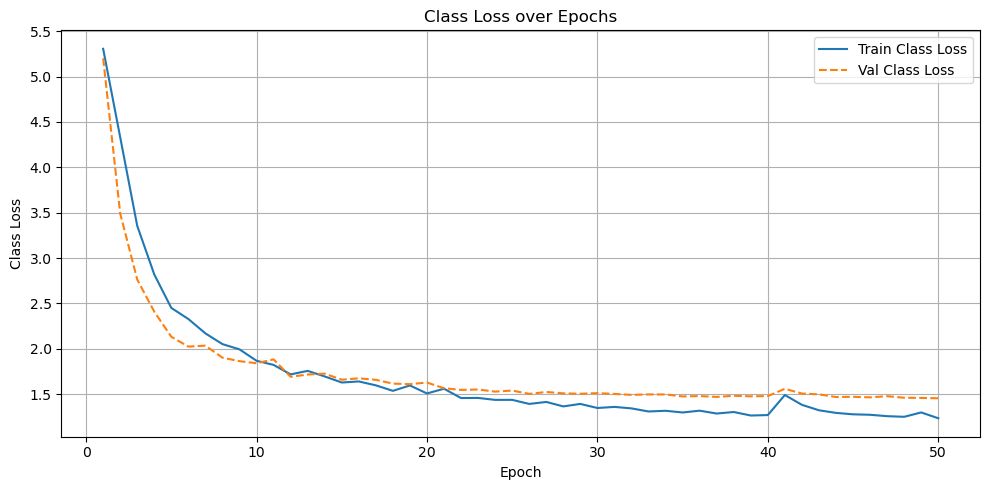

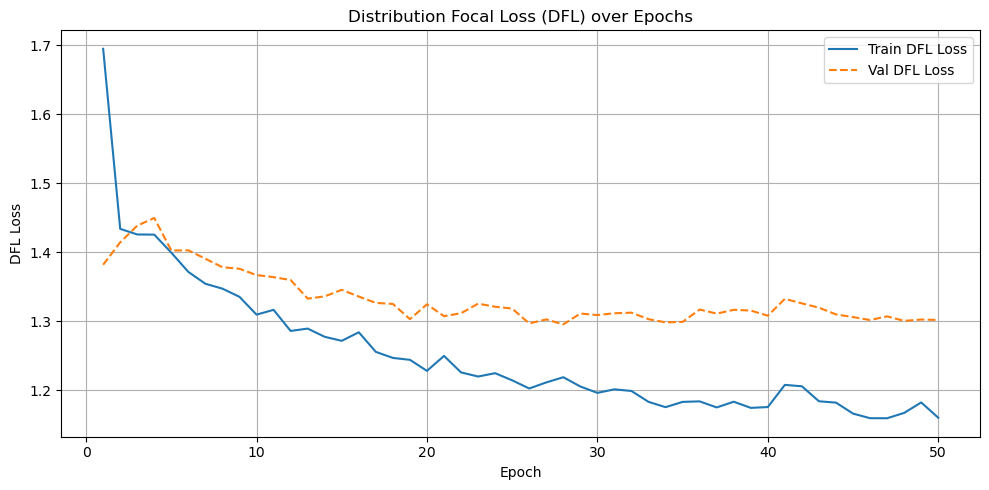

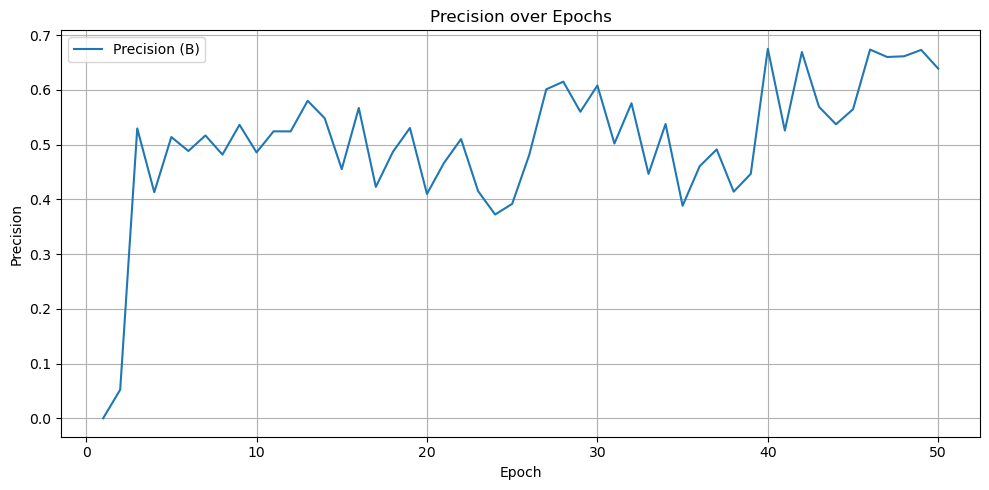

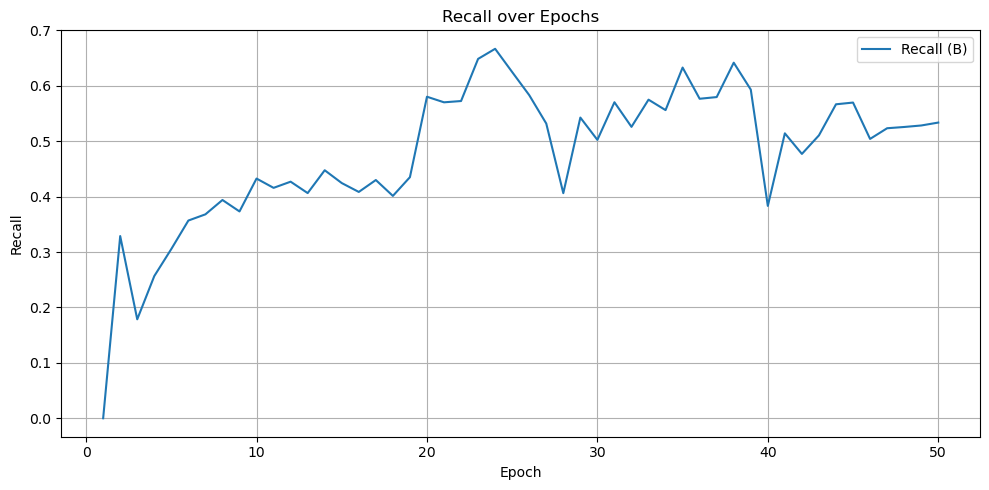

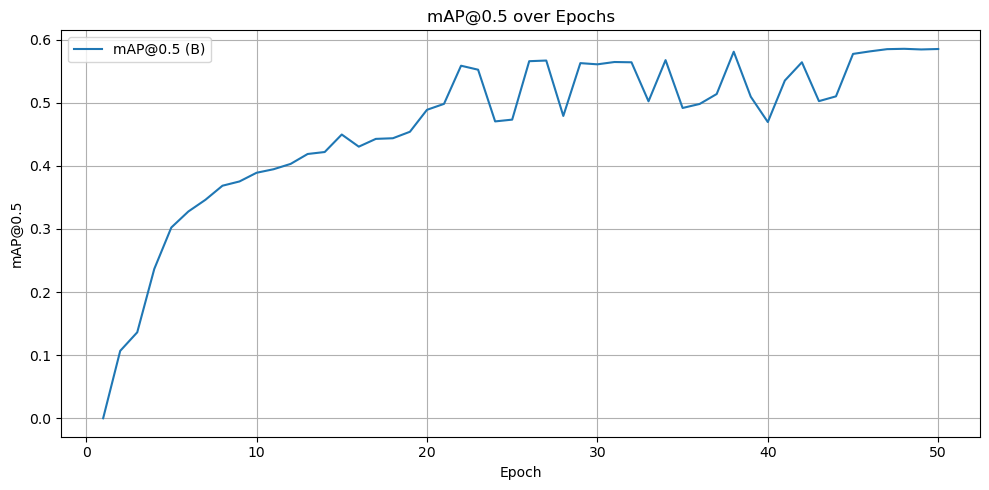

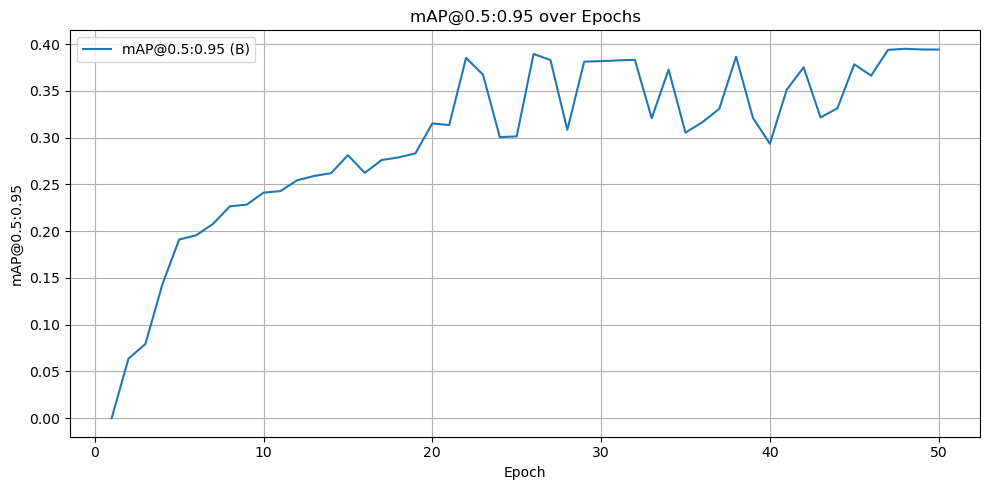

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv('runs/detect/train8/results.csv')  # Update path if needed

# Clean column names
df.columns = df.columns.str.strip()

# Define a helper function to plot each parameter
def plot_parameter(x, y_list, labels, title, ylabel):
    plt.figure(figsize=(10, 5))
    for y, label in zip(y_list, labels):
        plt.plot(df[x], df[y], label=label, linestyle='--' if 'Val' in label else '-')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot Box Loss
plot_parameter('epoch',
               ['train/box_loss', 'val/box_loss'],
               ['Train Box Loss', 'Val Box Loss'],
               'Box Loss over Epochs',
               'Box Loss')

# Plot Class Loss
plot_parameter('epoch',
               ['train/cls_loss', 'val/cls_loss'],
               ['Train Class Loss', 'Val Class Loss'],
               'Class Loss over Epochs',
               'Class Loss')

# Plot DFL Loss
plot_parameter('epoch',
               ['train/dfl_loss', 'val/dfl_loss'],
               ['Train DFL Loss', 'Val DFL Loss'],
               'Distribution Focal Loss (DFL) over Epochs',
               'DFL Loss')

# Plot Precision
plot_parameter('epoch',
               ['metrics/precision(B)'],
               ['Precision (B)'],
               'Precision over Epochs',
               'Precision')

# Plot Recall
plot_parameter('epoch',
               ['metrics/recall(B)'],
               ['Recall (B)'],
               'Recall over Epochs',
               'Recall')

# Plot mAP@0.5
plot_parameter('epoch',
               ['metrics/mAP50(B)'],
               ['mAP@0.5 (B)'],
               'mAP@0.5 over Epochs',
               'mAP@0.5')

# Plot mAP@0.5:0.95
plot_parameter('epoch',
               ['metrics/mAP50-95(B)'],
               ['mAP@0.5:0.95 (B)'],
               'mAP@0.5:0.95 over Epochs',
               'mAP@0.5:0.95')


In [2]:
    from ultralytics import YOLO
    
    # Load the trained model (best.pt or last.pt from your runs)
    model = YOLO('runs/detect/train8/weights/best.pt')  # Adjust path if needed
    
    # Run validation on the dataset
    metrics = model.val(
        data=r'C:\Users\akra0003\Desktop\JuypterInterior\data.yaml',
        split='val'  # explicitly using the validation set
    )
    
    # Print results
    print(metrics)


Ultralytics 8.3.172  Python-3.13.5 torch-2.7.1+cpu CPU (AMD EPYC 7V12 64-Core Processor)
Model summary (fused): 72 layers, 3,224,552 parameters, 0 gradients, 9.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 929.1603.8 MB/s, size: 232.8 KB)


val: Scanning C:\Users\akra0003\Desktop\JuypterInterior\valid\labels.cache... 230 images, 31 backgrounds, 16 corrupt: 1

val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\000d61ba9ffa87db.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\00bb967bc89e040f.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\0118064eedc2b2c1.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\0bf8a1dc0827950f.jpg: ignoring corrupt image/label: Label class 89 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\valid\images\0c0a7b8b641aa601.jpg: ignoring corrupt image/label: Label class 88 exceeds dataset class count 88. Possible class labels are 0-87
val: C:\Users\akra0003\Desktop\JuypterInterior\val


C:\Users\akra0003\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:12


                   all        214       1181      0.651      0.518      0.582      0.394
                  door         52         80      0.632      0.525      0.589      0.366
           cabinetDoor         93        731      0.828      0.684       0.79      0.446
      refrigeratorDoor         79        180      0.784      0.689      0.741      0.508
                window         33         81       0.48      0.284      0.278      0.149
                 table         20         38      0.784      0.526      0.699      0.429
               cabinet         28         38      0.341      0.158       0.21      0.108
            openedDoor         28         32      0.459      0.281      0.351       0.25
                  pole          1          1      0.899          1      0.995      0.895
Speed: 0.6ms preprocess, 40.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs\detect\val2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: arra

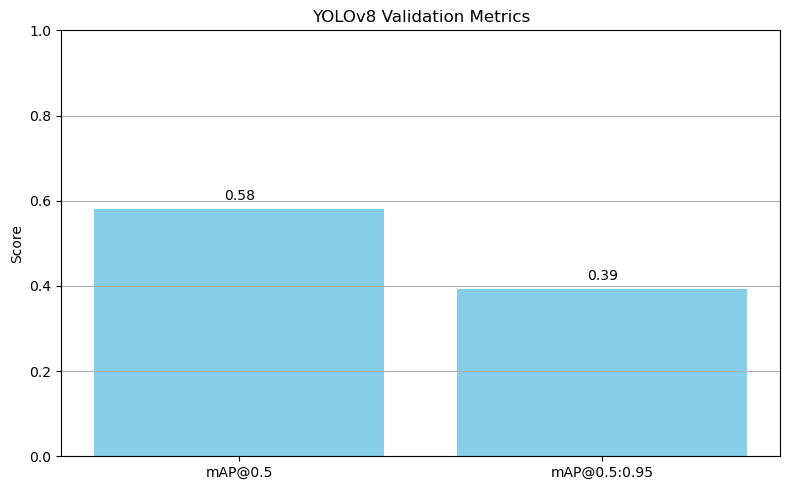

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

# Extract metrics
precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map50_95 = metrics.box.map

# Plot
#'Precision', 'Recall',
#precision, recall, 
metric_names = ['mAP@0.5', 'mAP@0.5:0.95']
metric_values = [map50, map50_95]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values, color='skyblue')
plt.ylim(0, 1.0)
plt.title('YOLOv8 Validation Metrics')
plt.ylabel('Score')
plt.grid(axis='y')

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', ha='center')

plt.tight_layout()
plt.show()


In [15]:
print("class_names:", len(class_names))
print("precision:", len(precision))
print("recall:", len(recall))
print("map50:", len(map50))
print("map5095:", len(map5095))


class_names: 88
precision: 8
recall: 8
map50: 8
map5095: 8
